In [16]:
import pandas as pd
df = pd.read_csv('./data/marketing_AB.csv')
display(df.head())

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [17]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279668,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [18]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['converted'] = df['converted'].astype(int)

In [21]:
df.columns = df.columns.str.replace(' ','_')

In [22]:
df.groupby('test_group').agg(
    convert_rate = ('converted','mean'),
    size = ('user_id','count'),
    avg_ads = ('total_ads','mean'),
    median_ads = ('total_ads','median'),
    std_ads = ('total_ads','std'),
).reset_index()
# even though two groups have imbalance data but both are large enough to conduce test

,test_group,convert_rate,size,avg_ads,median_ads,std_ads
0,ad,0.025547,564577,24.823365,13.0,43.750456
1,psa,0.017854,23524,24.761138,12.0,42.860720


In [23]:
map = {
    'Monday':0,
    'Tuesday':1,
    'Wednesday':2,
    'Thursday':3,
    'Friday':4,
    'Saturday':5,
    'Sunday':6
}
df['most_ads_day_num'] = df['most_ads_day'].map(map)

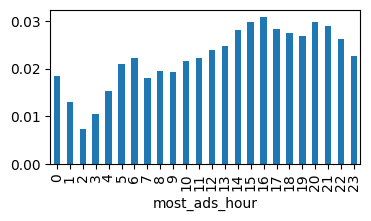

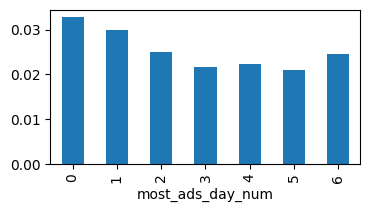

In [24]:
import matplotlib.pyplot as plt
for cat in ['most_ads_hour','most_ads_day_num']:
    group_df = df.groupby(cat)['converted'].mean()
    plt.figure(figsize=(4,2))
    group_df.plot(kind='bar')
    plt.show()

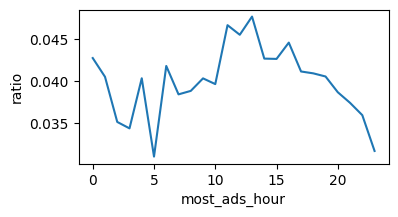

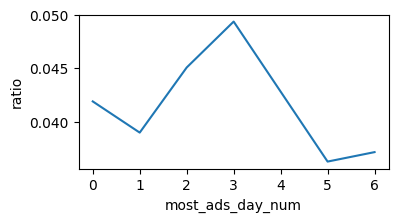

In [25]:
import seaborn as sns
for cat in ['most_ads_hour','most_ads_day_num']:
    group_df = df.groupby([cat,'test_group']).size().reset_index(name='count')
    pivot_df = pd.pivot_table(data=group_df,index=cat,columns='test_group',values='count',fill_value=0,aggfunc='sum')
    pivot_df['ratio'] = pivot_df['psa']/pivot_df['ad']
    plt.figure(figsize=(4,2))
    #sns.catplot(data=group_df,x=cat,y='count',hue='test group',kind='bar')
    sns.lineplot(data=pivot_df,x=cat,y='ratio')
    plt.show()

In [26]:
# test total ads impact
from scipy.stats import mannwhitneyu
ads = df[df['test_group']=='ad']['total_ads']
psa = df[df['test_group']=='psa']['total_ads']
mannwhitneyu(ads,psa)

MannwhitneyuResult(statistic=np.float64(6808288222.0), pvalue=np.float64(4.6909108547205694e-11))

In [27]:
# test categorical variable
from scipy.stats import chi2_contingency
table = pd.crosstab(df['test_group'],df['most_ads_day'])
chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(235.61445227291117), pvalue=np.float64(4.849067664297988e-48), dof=6, expected_freq=array([[88903.68629878, 83590.08592232, 78393.60555415, 81975.36580791,
        79662.72564406, 74379.84526978, 77671.685503  ],
       [ 3704.31370122,  3482.91407768,  3266.39444585,  3415.63419209,
         3319.27435594,  3099.15473022,  3236.314497  ]]))

In [28]:
table = pd.crosstab(df['test_group'],df['most_ads_hour'])
chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(192.29173193613582), pvalue=np.float64(1.0945739710814025e-28), dof=23, expected_freq=array([[5.31456038e+03, 4.60992033e+03, 5.11968036e+03, 2.57184018e+03,
        6.93120049e+02, 7.34400052e+02, 1.98528014e+03, 6.14880044e+03,
        1.69219212e+04, 2.97638421e+04, 3.73814426e+04, 4.43616031e+04,
        4.54060832e+04, 4.57488032e+04, 4.38220831e+04, 4.28956830e+04,
        3.60643226e+04, 3.35884824e+04, 3.10300822e+04, 2.91379221e+04,
        2.77660820e+04, 2.87769620e+04, 2.53747218e+04, 1.93593614e+04],
       [2.21439623e+02, 1.92079673e+02, 2.13319637e+02, 1.07159818e+02,
        2.88799509e+01, 3.05999480e+01, 8.27198593e+01, 2.56199564e+02,
        7.05078801e+02, 1.24015789e+03, 1.55755735e+03, 1.84839686e+03,
        1.89191678e+03, 1.90619676e+03, 1.82591690e+03, 1.78731696e+03,
        1.50267744e+03, 1.39951762e+03, 1.29291780e+03, 1.21407794e+03,
        1.15691803e+03, 1.19903796e+03, 1.05727820e+03, 8.06638628e+02]]))

In [29]:
# since p-value all small and reject null hypothesis, fit model for covariate
import statsmodels.formula.api as smf
model = smf.logit(
    'converted ~ C(test_group) + total_ads + C(most_ads_day) + C(most_ads_hour)',
    data=df
).fit()
print(model.summary())
# this also evaluate treatment effect on converted, then compare with z-test significance

Optimization terminated successfully.
         Current function value: 0.108125
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588069
Method:                           MLE   Df Model:                           31
Date:                Thu, 28 May 2026   Pseudo R-squ.:                 0.08198
Time:                        22:20:55   Log-Likelihood:                -63588.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -4.5602      0.106    -43.120      0.000

In [31]:
# check sample ratio mismatch (SRM)
from scipy.stats import chisquare
observed = df['test_group'].value_counts().sort_index().values
expected = [len(df)/2, len(df)/2]
chi2, p_value = chisquare(observed, f_exp=expected)
print(p_value)

0.0


In [32]:
# randomization balance
num_cols = ['total_ads', 'most_ads_day_num', 'most_ads_hour']
df.groupby('test_group')[num_cols].mean()

,total_ads,most_ads_day_num,most_ads_hour
test_group,,,
ad,24.823365,3.028570,14.475900
psa,24.761138,2.952644,14.304923


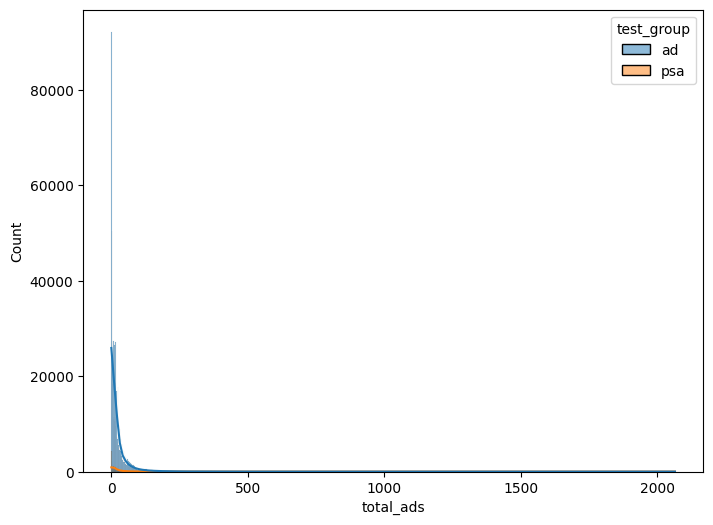

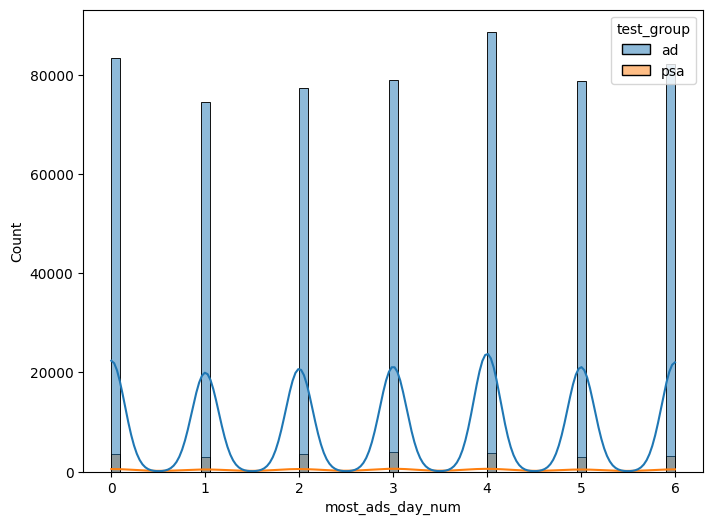

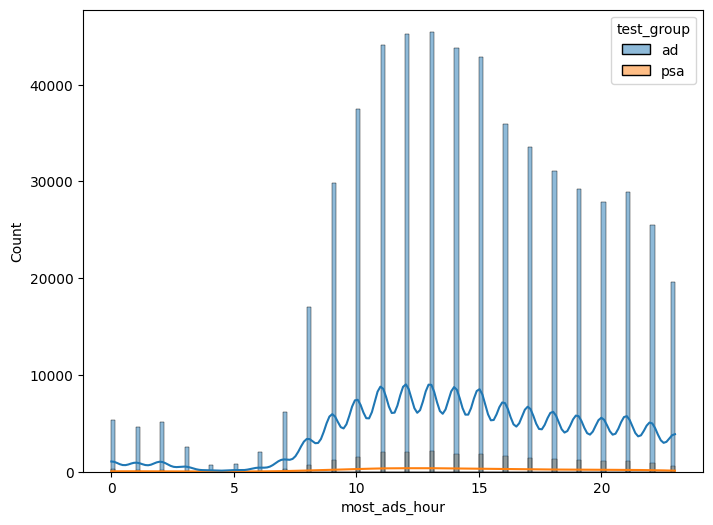

In [33]:
# distribution
import seaborn as sns
import matplotlib.pyplot as plt
for col in num_cols:
    plt.figure(figsize=(8,6))
    sns.histplot(data=df, x=col, hue='test_group', kde=True)
    plt.show()

<Axes: xlabel='most_ads_day_num', ylabel='converted'>

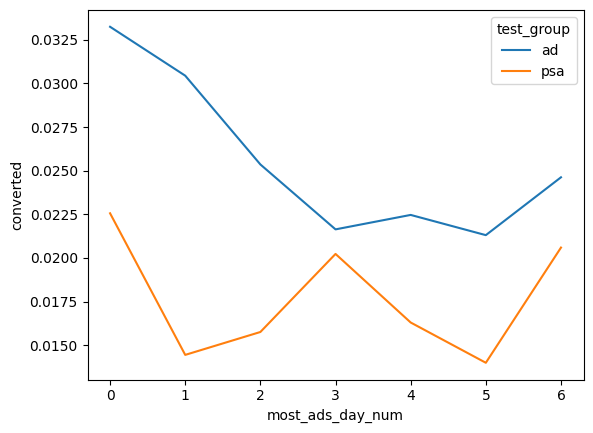

In [34]:
# check conversion by day
sns.lineplot(data=df.groupby(['test_group', 'most_ads_day_num'])['converted'].mean().reset_index(),
             x='most_ads_day_num', y='converted', hue='test_group')

In [36]:
# CLT assumption for z test
summary = df.groupby('test_group')['converted'].agg(['sum','count'])
summary['failures'] = summary['count'] - summary['sum']
summary['p'] = summary['sum'] / summary['count']
summary['np'] = summary['count'] * summary['p']
summary
# np>=5 and n(1-p)>=5, if assumption fails: fisher, bootstrap, and bayesian methods can be used

,sum,count,failures,p,np
test_group,,,,,
ad,14423,564577,550154,0.025547,14423.0
psa,420,23524,23104,0.017854,420.0


In [37]:
# run z test
import numpy as np
def manual_cvr_ztest(df,group_col='test_group'):
    summary = df.groupby(group_col)['converted'].agg(['count','mean']).reset_index()
    total = df['converted'].mean()
    p1 = summary.loc[summary[group_col] == 'ad', 'mean'].values[0]
    p2 = summary.loc[summary[group_col] == 'psa', 'mean'].values[0]
    n1 = summary.loc[summary[group_col] == 'ad', 'count'].values[0]
    n2 = summary.loc[summary[group_col] == 'psa', 'count'].values[0]
    p_pool = total
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z_stat = (p1 - p2) / se_pool
    from scipy.stats import norm
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))
    return z_stat, p_value

In [38]:
result = manual_cvr_ztest(df)
print(f"Z-statistic: {result[0]}, P-value: {result[1]}")

Z-statistic: 7.3700781265454145, P-value: 1.7053025658242404e-13


In [40]:
# confidence interval of life
count_c = df[df['test_group']=='psa']['converted'].sum()
nobs_c = df[df['test_group']=='psa']['converted'].count()
count_t = df[df['test_group']=='ad']['converted'].sum()
nobs_t = df[df['test_group']=='ad']['converted'].count()
p_c = count_c/nobs_c
p_t = count_t/nobs_t
lift = p_t - p_c
se = (p_c * (1 - p_c)/nobs_c + p_t * (1 - p_t)/nobs_t) ** 0.5
ci_low = lift - 1.96 * se
ci_high = lift + 1.96 * se
print(f'95% CI: [{ci_low:.4f},{ci_high:.4f}]')

95% CI: [0.0060,0.0094]


The treatment group shows a statistically significant increase in conversion compared with the control group. The estimated conversion lift is between 0.60 and 0.94 percentage points. Since the confidence interval is entirely positive and the p-value is very small, I recommend moving forward with the treatment, assuming no negative impact is found in guardrail metrics such as user experience, retention, cost, or ad exposure quality.

In [ ]:
# coef = 0.3862 from ols model
odds_ratio = np.exp(0.3862) - 1
print(odds_ratio) # 47% higher odds of converting in Ads than PSA, CI is showing actual lift 0.6% to 0.94%

1.471378917172561
